# 🐯 TIGeR — Corrected Detection Run (synthetic catalogue)

Regenerates the **detection** table: precision / recall / F1 and per-error-type
recall on the seeded synthetic catalogue.

**Scope changed.** This notebook previously also ran the Kaggle Myntra fashion
set. Both real-data verticals now come from official ABO — see
`tiger_abo_corrected_run.ipynb`. What remains here is the synthetic benchmark,
which is where the project's strongest verified result lives: a
CLIP-similarity-only detector catches **0.267** of text mutations, and the
per-field contrastive probes lift that to **0.853**.

That result is independent of the dataset migration, so this notebook is
unaffected by it — but it does need re-running, because `synthgen` has been
unbuildable since the ABO schema edit (D5) and the per-signal precision floor
now scores each probe against the error it names rather than any dirty row (A8).

**What was wrong with the harness**

| # | Defect | Effect |
|---|---|---|
| A8 | Per-signal precision counted any dirty row as a hit | The 0.85 floor certified "fires on dirty rows", not "identifies the error it names". Expect some probes to be quarantined now that were not. |
| A7 | Fusion was never loaded by `detect` | The advertised P=0.888 was an offline ablation row; the live pipeline ran at P=0.793. Now opt-in via `--fusion`. |
| D5 | Five colours were both domain values and aliases | Probes scored duplicates as rivals, and `synthgen` crashed on ~1/3 of products. |

**Runtime:** ~15–25 min on a T4. *Notebook options → Accelerator → GPU T4 x2.*

## Step 0 · Clone the fixed branch and install

In [1]:
!rm -rf TIGeR-Text-Image-Generative-Repair
!git clone -q -b master https://github.com/abdullah2142/TIGeR-Text-Image-Generative-Repair.git
%cd TIGeR-Text-Image-Generative-Repair
!git log --oneline -1

# H7: never use --force-reinstall here. It rebuilds the whole dependency tree,
# pulls an incompatible torchvision, and every later cell dies with
# "operator torchvision::nms does not exist". Clear only the local package.
!pip uninstall -y tiger -q 2>/dev/null
!pip install --no-cache-dir -e ".[dev,vlm,gen]" -q
print("\n✅ installed")

/kaggle/working/TIGeR-Text-Image-Generative-Repair
b7c6c8f (HEAD -> master, origin/master, origin/HEAD) Resolve the encoder device instead of hardcoding cpu
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for tiger (pyproject.toml) ... done

✅ installed


## Step 1 · Guard: confirm the fixes are present

Cheap, and it fails loudly. Cloning the wrong branch otherwise wastes the run
and produces numbers that look plausible and are not.

In [2]:
import inspect
from tiger import cli
from tiger.schema import Schema, load_schema
from tiger.fusion import PROBE_TARGETS
from tiger.eval import repair_ablation as RA
from pathlib import Path

checks = []
def check(name, ok, detail=""):
    checks.append((name, bool(ok), detail))

src = inspect.getsource(RA.run_repair_ablations)
check("A1  gamma written to cfg['arbiter']",
      'cfg_no_gamma.setdefault("arbiter", {})["gamma"] = 0.0' in src)
check("A4  configs deep-copied", "copy.deepcopy(cfg)" in src)
check("A3  baseline emits no E4 key",
      '"E4"' not in inspect.getsource(RA.DummyArbiter.predict_proba))
check("A3b baseline is seeded",
      "seed" in inspect.signature(RA.DummyArbiter.__init__).parameters)
check("A5  every audited field scored", hasattr(RA, "truth_from_audit"))
check("A5  image repairs scored", hasattr(RA, "image_provenance"))
check("A7  --fusion flag exposed", '"--fusion"' in inspect.getsource(cli.main))
check("A8  probes scored on-target", isinstance(PROBE_TARGETS, dict) and "color" in PROBE_TARGETS)
check("D5  surface_forms available", hasattr(Schema, "surface_forms"))

# --- Phase 1: the ABO vertical migration ---
from tiger.data.import_abo import CATEGORY_MAP, VERTICALS
from tiger.data import abo_vocab

check("P1  two ABO verticals defined",
      set(VERTICALS) == {"furnishing", "accessories"} and len(CATEGORY_MAP) == 15,
      f"{len(CATEGORY_MAP)} product types")
check("P1  phone cases excluded", "CELLULAR_PHONE_CASE" not in CATEGORY_MAP)
check("P1  colour normaliser present", hasattr(abo_vocab, "normalize_color"))
check("P1  legacy config.yaml gone", not Path("configs/config.yaml").exists())

schema = load_schema("configs/schema.yaml")
dom = schema.domain("color")
check("D5  no duplicate colours in the domain",
      len(dom) == len({schema.normalize("color", v) for v in dom}),
      f"{len(dom)} entries: {dom}")

from tiger.data.synthgen import COLOR_RGB
missing = [c for c in dom if c != "multicolour" and c not in COLOR_RGB]
check("D5  synthgen can render every colour", not missing, f"missing: {missing}")

cfg = cli.load_cfg()
allowed = cfg["arbiter"]["t2v_policy"]["allowed_categories"]
missing_t2v = sorted(set(CATEGORY_MAP.values()) - set(allowed))
check("A6  every ABO category is T2V-eligible", not missing_t2v,
      f"missing: {missing_t2v}" if missing_t2v else f"{len(allowed)} allowed")
check("P1  no ABO category requires colour",
      not (set(CATEGORY_MAP.values())
           & set(schema.attributes["color"].get("required_for_categories", []))),
      "measured coverage is 45-93%; requiring it repeats H10")

# --- 2026-09-14: the estimator rebuild and the routing fixes ---
from tiger import colors, solver, arbiter, sieve
from tiger.generator import build_prompt

check("B2  product localised by connectivity, not a fixed box",
      hasattr(colors, "select_region") and hasattr(colors, "background_mask"))
check("B2  estimate records which region it measured",
      "region" in colors.ColorEstimate.__dataclass_fields__)
check("B5  resize preserves aspect ratio",
      "max(w, h)" in inspect.getsource(colors._load_rgb))
check("B8  value decides at the dark end",
      "dark = v <= BLACK_V_MAX" in inspect.getsource(colors.estimate_dominant_color))
check("B9  a declined colour is not a disagreement",
      "pixel_declined" in solver.RepairPlan.__dataclass_fields__)
check("B4  pixel share is named a share, not a confidence",
      hasattr(solver, "PIXEL_SHARE_MIN"))
check("D1  calibration measured every run", hasattr(arbiter, "calibration_report"))
check("D10 pattern and material reach the T2V prompt",
      "striped pattern" in build_prompt("x", "chair",
                                        {"color": "red", "pattern": "striped"})[1])
check("D10 generator uses the shared singular table",
      build_prompt("x", "wall_art", {"color": "blue"})[1] == "blue piece of wall art")

# D15: the title check must not fire on a title that merely lists colours,
# nor on jewellery metal names. Both were ~93% of the dismiss blockage.
_tc = lambda t: sieve._title_color(t, schema, "")
check("D15 multi-colour titles are not contradictions",
      _tc("Wool Area Rug, Blue, Grey, Brown") == "")
check("D15 jewellery metal names are materials",
      _tc("Sterling Silver Halo Pendant Necklace") == "")
check("D15 a single contradicting colour still fires",
      _tc("Solid Red Dining Chair") == "red")

# D14: the dismiss guard must be STRICTER than the Sieve threshold that flags
# the row, or it vetoes every row it is asked about.
_gz = float(cfg["arbiter"].get("dismiss_contrary_z", -2.0))
_fz = -float(cfg["sieve"]["probes"]["z_margin"])
check("D14 dismiss guard is stricter than the flag threshold",
      _gz < _fz, f"guard {_gz} vs flag {_fz}")

check("D17 T2V verifier can reject a choice",
      "runner_up_image_path" in inspect.signature(
          __import__("tiger.verify", fromlist=["x"]).IndependentVerifier.check_t2v).parameters)

check("B7  probes on SigLIP, scoring stays on CLIP",
      (cfg["models"].get("probe_model_name") == "google/siglip-base-patch16-224"
       and cfg["models"]["clip_model_name"] == "openai/clip-vit-base-patch32"),
      cfg["models"].get("probe_model_name", "(unset)"))

import torch as _t
check("PERF encoders will use the GPU",
      cli.resolve_device(cfg["models"].get("device", "cpu")) == "cuda",
      f'device={cfg["models"].get("device")} -> '
      f'{cli.resolve_device(cfg["models"].get("device", "cpu"))}; '
      f'cuda_available={_t.cuda.is_available()}')

check("D19 weak signals cannot veto a dismissal",
      "title_contradiction" not in cfg["arbiter"].get("dismiss_contrary_signals", ["title_contradiction"]),
      str(cfg["arbiter"].get("dismiss_contrary_signals", "(unset)")))

width = max(len(n) for n, _, _ in checks)
for name, ok, detail in checks:
    print(f"{'PASS' if ok else 'FAIL'}  {name:<{width}}  {detail}")

failed = [n for n, ok, _ in checks if not ok]
assert not failed, f"\n\nWRONG BRANCH OR STALE INSTALL. Missing: {failed}"
print("\n✅ all fixes present — safe to proceed")

PASS  A1  gamma written to cfg['arbiter']                     
PASS  A4  configs deep-copied                                 
PASS  A3  baseline emits no E4 key                            
PASS  A3b baseline is seeded                                  
PASS  A5  every audited field scored                          
PASS  A5  image repairs scored                                
PASS  A7  --fusion flag exposed                               
PASS  A8  probes scored on-target                             
PASS  D5  surface_forms available                             
PASS  P1  two ABO verticals defined                           15 product types
PASS  P1  phone cases excluded                                
PASS  P1  colour normaliser present                           
PASS  P1  legacy config.yaml gone                             
PASS  D5  no duplicate colours in the domain                  12 entries: ['red', 'blue', 'green', 'black', 'white', 'yellow', 'pink', 'purple', 'brown', 'orange', '

## Step 2 · Test suite (162)

In [3]:
!python -m pytest -q 2>&1 | tail -5

........................................................................ [ 30%]
........................................................................ [ 60%]
........................................................................ [ 90%]
.......................                                                  [100%]


## Step 3 · Pin γ and record it with the run

γ has had four different values across the repo (0.40 in the config, 0.60 in
the docs and the ABO analysis, 0.85 in `paper_concepts.md`, 0.448 recalibrated).
Nobody can say which produced which published number — that is finding C1, and
it happened because recalibration edits `configs/tiger.yaml` in place with no
record.

Set it **once**, here, and write the effective values into the outputs so this
run is self-documenting.

`GAMMA = 0.60` reproduces the operating point the Fashion tables were built at
(the committed confidence histogram is captioned "Gamma threshold (0.6)").
Change it only deliberately.

In [4]:
import json, re, yaml
from pathlib import Path

GAMMA = 0.60          # operating point for THIS run
NOISE_SEED = 7
BASELINE_SEED = 42    # seeds the random-routing baseline (A3b)

cfg_path = Path("configs/tiger.yaml")
text = cfg_path.read_text()

# Surgical line edit, NOT yaml.safe_dump: dumping would round-trip the file and
# silently delete every comment in it, including the rationale for the T2V
# allowlist and the noise rates. Config comments are the only place several of
# these decisions are recorded.
# Replace the whole line including its trailing comment. Leaving the old
# comment behind ("lowered from 0.60 ...") next to a value of 0.60 is precisely
# the config/doc drift that produced finding C1 in the first place.
text, n = re.subn(
    r"^(\s*)gamma:.*$",
    rf"\g<1>gamma: {GAMMA}  # Eq. 22 confidence gate; pinned by tiger_corrected_run.ipynb",
    text, count=1, flags=re.M)
assert n == 1, "could not find `gamma:` in configs/tiger.yaml"

if not re.search(r"^eval:", text, flags=re.M):
    text += ("\neval:\n"
             "  # Seeds the random-routing baseline so the 'No Arbiter' row is\n"
             "  # reproducible (finding A3b).\n"
             f"  random_baseline_seed: {BASELINE_SEED}\n")
else:
    text, n = re.subn(r"^(\s*random_baseline_seed:\s*)\d+", rf"\g<1>{BASELINE_SEED}",
                      text, count=1, flags=re.M)
    assert n == 1
cfg_path.write_text(text)

cfg = yaml.safe_load(cfg_path.read_text())
assert cfg["arbiter"]["gamma"] == GAMMA
assert cfg["eval"]["random_baseline_seed"] == BASELINE_SEED

manifest = {
    "branch": "docs/fixes-backlog-audit",
    "gamma": GAMMA,
    "noise_seed": NOISE_SEED,
    "random_baseline_seed": BASELINE_SEED,
    "dismiss_threshold": cfg["arbiter"]["dismiss_threshold"],
    "t2v_allowed_categories": cfg["arbiter"]["t2v_policy"]["allowed_categories"],
    "precision_floor": cfg["sieve"]["precision_floor"],
    "clip_model": cfg["models"]["clip_model_name"],
    "independent_verifier": cfg["models"]["independent_verifier"],
    "fusion_applied": False,
}
Path("data/outputs").mkdir(parents=True, exist_ok=True)
Path("data/outputs/run_manifest.json").write_text(json.dumps(manifest, indent=2))
print(json.dumps(manifest, indent=2))


{
  "branch": "docs/fixes-backlog-audit",
  "gamma": 0.6,
  "noise_seed": 7,
  "random_baseline_seed": 42,
  "dismiss_threshold": 0.8,
  "t2v_allowed_categories": [
    "shirts",
    "shoes",
    "bags",
    "hats",
    "chair",
    "sofa",
    "table",
    "ottoman",
    "stool",
    "rug",
    "lamp",
    "light_fixture",
    "wall_art",
    "ring",
    "necklace",
    "earring",
    "handbag",
    "suitcase",
    "hat"
  ],
  "precision_floor": 0.85,
  "clip_model": "openai/clip-vit-base-patch32",
  "independent_verifier": "google/siglip-base-patch16-224",
  "fusion_applied": false
}


---
# Phase A · Synthetic catalogue → detection numbers

Regenerates the detection table (precision / recall / F1 and per-error-type
recall). `synthgen` has been unbuildable since the ABO schema edit — D5 is what
makes this step run at all.

In [5]:
!python -m tiger.cli synthgen

generated 1141 products -> data/sample/products.parquet
category       split      
bags           calibration    31
               report         29
chair          calibration    32
               report         28
earring        calibration    30
               report         30
handbag        calibration    27
               report         33
hat            calibration    35
               report         25
hats           calibration    29
               report         31
lamp           calibration    31
               report         29
light_fixture  calibration    27
               report         33
necklace       calibration    28
               report         32
ottoman        calibration    30
               report         30
ring           calibration    30
               report         30
rug            calibration    35
               report         25
shirts         calibration    30
               report         30
shoes          calibration    32
               report     

In [6]:
!python -m tiger.cli calibrate

locked thresholds -> /kaggle/working/TIGeR-Text-Image-Generative-Repair/data/thresholds/tiger_locked_thresholds.json
LOO calibration -> /kaggle/working/TIGeR-Text-Image-Generative-Repair/data/thresholds/tiger_loo_calibration.json
verify epsilon=0.0289 (by category: {'chair': 0.0242, 'sofa': 0.0227, 'table': 0.0216, 'ottoman': 0.0302, 'stool': 0.0286, 'rug': 0.0239, 'lamp': 0.0275, 'light_fixture': 0.0338, 'wall_art': 0.0329, 'ring': 0.0276, 'necklace': 0.0264, 'earring': 0.0372, 'handbag': 0.0195, 'suitcase': 0.0254, 'hat': 0.0179, 'shirts': 0.0369, 'shoes': 0.0311, 'bags': 0.0238, 'hats': 0.02}) -> /kaggle/working/TIGeR-Text-Image-Generative-Repair/data/thresholds/tiger_verify_calibration.json


**`train-arbiter` is the slow one** — it runs eight noise seeds end to end. Expect several minutes.

In [7]:
!python -m tiger.cli train-arbiter

wrote /kaggle/working/TIGeR-Text-Image-Generative-Repair/data/processed/noisy_report_cal_seed1007.parquet
{
  "seed": 1007,
  "copies_per_row": 1,
  "rates": {
    "swap_image": 0.1,
    "swap_image_same_category": 0.03,
    "color_flip": 0.06,
    "near_color_flip": 0.02,
    "material_flip": 0.02,
    "attribute_drop": 0.02,
    "title_contradiction": 0.02,
    "mixed_swap_color": 0.02,
    "missing_image": 0.01
  },
  "rows_total": 569,
  "rows_noisy": 169,
  "by_label": {
    "clean": 400,
    "mutate_text": 78,
    "swap_image": 74,
    "mixed": 11,
    "missing_image": 6
  },
  "by_subtype": {
    "swap_image": 57,
    "color_flip": 34,
    "swap_image_same_category": 17,
    "near_color_flip": 11,
    "title_contradiction": 11,
    "attribute_drop": 11,
    "mixed_swap_color": 11,
    "material_flip": 11,
    "missing_image": 6
  },
  "self_verified": true
}


📊 Stage 1: Error Detection Complete
--------------------------------------------------
operating point: full (OR-fused s

In [8]:
!python -m tiger.cli calibrate-fusion

precision floor 0.85; calibrated on 4552 labelled rows
  flag_probe_color           precision=0.861 fired=1070 z>=2.0
  flag_probe_material        precision=1.0 fired=3 z>=4.0
  flag_probe_pattern         precision=0.919 fired=359 z>=2.5
  flag_low_sim               precision=0.871 fired=812
  flag_text_out_of_domain    precision=1.0 fired=17
  flag_title_contradiction   precision=1.0 fired=88
wrote /kaggle/working/TIGeR-Text-Image-Generative-Repair/data/thresholds/tiger_fusion.json


### Detection sweep and ablations

`calibrate-fusion` output above is worth reading closely: A8 changed how
per-signal precision is scored, so a signal that previously cleared the 0.85
floor may now be quarantined. That is the correction working.

In [9]:
!python -m tiger.cli sweep --seeds 7,8,9,10,11

wrote /kaggle/working/TIGeR-Text-Image-Generative-Repair/data/processed/noisy_report_seed7.parquet
{
  "seed": 7,
  "copies_per_row": 1,
  "rates": {
    "swap_image": 0.1,
    "swap_image_same_category": 0.03,
    "color_flip": 0.06,
    "near_color_flip": 0.02,
    "material_flip": 0.02,
    "attribute_drop": 0.02,
    "title_contradiction": 0.02,
    "mixed_swap_color": 0.02,
    "missing_image": 0.01
  },
  "rows_total": 572,
  "rows_noisy": 170,
  "by_label": {
    "clean": 402,
    "mutate_text": 78,
    "swap_image": 74,
    "mixed": 11,
    "missing_image": 7
  },
  "by_subtype": {
    "swap_image": 57,
    "color_flip": 34,
    "swap_image_same_category": 17,
    "near_color_flip": 11,
    "mixed_swap_color": 11,
    "attribute_drop": 11,
    "title_contradiction": 11,
    "material_flip": 11,
    "missing_image": 7
  },
  "self_verified": true
}


📊 Stage 1: Error Detection Complete
--------------------------------------------------
operating point: full (OR-fused signals)
Ou

In [10]:
!python -m tiger.cli ablate --seeds 7,8,9,10,11

=== baselines & ablations (5 seeds pooled) ===

📊 Ablation Study: Which components matter?

Configuration         Precision   Recall       F1
--------------------------------------------------
Random Baseline           0.313    0.369    0.339
Text Checks Only          1.000    0.084    0.154
CLIP Score Only           0.783    0.543    0.641
Probes Only               0.789    0.729    0.758
No Probes                 0.802    0.612    0.695
Full System               0.738    0.869    0.798
Full + Fusion Gate        0.761    0.867    0.811

Per-Error-Type Recall:
----------------------------------------------------------------------
Configuration        missing_imag         mixed   mutate_text    swap_image
---------------------------------------------------------------------------
Random Baseline             0.457         0.309         0.382         0.355
Text Checks Only            0.143         0.000         0.169         0.000
CLIP Score Only             1.000         0.691         0.

## Results

Two columns are new (A5). `Attr Accuracy` covers colour, material and pattern
instead of colour alone; `T2V Accuracy` scores image repairs, which were
previously not scored at all. Every metric now carries its own N — the old
headline was 52.6% on n=19 and the denominator appeared only in a LaTeX caption.

In [11]:
!python -m tiger.cli ablate-repair --independent --generative-fallback


[config] effective arbiter.gamma = 0.6 (from config)
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Loading pipeline components...: 100%|█████████████| 7/7 [00:02<00:00,  3.42it/s]
  Sampled 170 corrupted + 340 clean = 510 total rows

Running repair ablations on the full dataset...
1/5: Running 'Full System'...
  wrote repaired_report_seed7.parquet and repair_report_seed7.json (Full System, per-row)
2/5: Running 'No Arbiter (Random Routing)'...
3/5: Running 'No Independent Verifier'

In [12]:
import pandas as pd
pd.set_option("display.width", 200, "display.max_columns", 50)

df = pd.read_csv("data/outputs/repair_ablations_summary.csv")
cols = [c for c in ["Configuration", "Repaired", "Escalated", "Total Attempted",
                    "Attr Accuracy", "Attr Cases", "T2V Accuracy", "T2V Cases",
                    "Color Accuracy", "V2T Cases"] if c in df.columns]
display(df[cols])

full = df[df["Configuration"] == "Full System"]
nog  = df[df["Configuration"].str.contains("Gamma", na=False)]
if len(full) and len(nog):
    same = (full["Repaired"].iat[0] == nog["Repaired"].iat[0]
            and full["Escalated"].iat[0] == nog["Escalated"].iat[0])
    print("\nGamma gate row vs Full System:",
          "STILL IDENTICAL — investigate, A1 should have separated these" if same
          else "different ✅ — the gate is now genuinely ablated")

,Configuration,Repaired,Escalated,Total Attempted,Attr Accuracy,Attr Cases,T2V Accuracy,T2V Cases,Color Accuracy,V2T Cases
0,No Arbiter (Random),1,181,182,1.000000,1,NaN,0,1.000000,1
1,No Independent Verifier,22,137,159,0.785714,14,0.700000,10,0.785714,14
2,No Generative Fallback,21,138,159,0.785714,14,0.666667,9,0.785714,14
3,No Gamma Gate (gamma=0),50,108,158,0.750000,28,0.588235,17,0.750000,28
4,Full System,21,138,159,0.785714,14,0.666667,9,0.785714,14



Gamma gate row vs Full System: different ✅ — the gate is now genuinely ablated


In [13]:
import json
from pathlib import Path

d4 = json.loads(Path("data/outputs/repair_ablations.json").read_text()).get("full", {})
dist = d4.get("passes_used_distribution", {})
multi = d4.get("multi_pass_rows", 0)
both = d4.get("both_directions_rows", 0)

print("--- D4: did any row actually get a second pass? ---")
print(f"passes_used distribution (Full System): {dist}")
print(f"rows that reached pass 2+: {multi}")
print(f"rows that got BOTH a T2V and a V2T repair (the direct signature of D4 working): {both}")
if multi and both:
    print("Non-zero on both \u2705 \u2014 the two-pass re-diagnosis loop fired on real rows,")
    print("not just in the unit tests (tests/test_repair_two_pass.py).")
else:
    print("Zero here does not mean D4 is broken \u2014 it means no row in this sample")
    print("needed both an image and a text fix this run. Check the E3/BOTH share of")
    print("the Arbiter's routing output (cell above) to see how common that should be.")


--- D4: did any row actually get a second pass? ---
passes_used distribution (Full System): {'1': 179, '2': 10}
rows that reached pass 2+: 10
rows that got BOTH a T2V and a V2T repair (the direct signature of D4 working): 0
Zero here does not mean D4 is broken — it means no row in this sample
needed both an image and a text fix this run. Check the E3/BOTH share of
the Arbiter's routing output (cell above) to see how common that should be.


### V2T estimator attribution

Every colour repair records which estimator supplied the value (the HSV pixel
histogram or the CLIP probe) and whether the *other* one would have been right.

This report decides what to work on next: if `always pixel` far exceeds
`always probe`, the encoder is the bottleneck (B7); if the reverse, the colour
estimator is (B1–B5, currently blocked on having this data locally). The
`agree / disagree` split sizes what an abstention gate would buy — that is the
parked ⚑ item B6.

In [14]:
import pandas as pd
from pathlib import Path

p = Path("data/outputs/v2t_estimator_diagnostics.csv")
if p.exists():
    d = pd.read_csv(p)
    display(d.head(30))
    print("\nrows:", len(d))
else:
    print("No scored V2T cases in this run — nothing to attribute.")

,config,row_id,true_color,written_color,correct,value_source,pixel_value,pixel_conf,pixel_region,pixel_declined,probe_value,estimators_agree,pixel_correct,probe_correct
0,full,bags_010,purple,white,0.0,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
1,full,bags_024,pink,pink,1.0,pixel,pink,0.867321,foreground,False,pink,True,1.0,1.0
2,full,bags_041,brown,pink,0.0,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
3,full,chair_018,black,NaN,NaN,pixel,black,0.855550,foreground,False,brown,False,1.0,0.0
4,full,earring_002,orange,orange,1.0,pixel,orange,0.768801,foreground,False,orange,True,1.0,1.0
5,full,earring_008,green,green,1.0,pixel,green,0.712205,foreground,False,green,True,1.0,1.0
6,full,hats_033,red,red,1.0,pixel,red,0.881527,foreground,False,red,True,1.0,1.0
7,full,hats_049,gray,NaN,NaN,pixel,gray,0.584983,foreground,False,green,False,1.0,0.0
8,full,hats_059,blue,blue,1.0,pixel,blue,0.928695,foreground,False,blue,True,1.0,1.0
9,full,lamp_035,brown,brown,1.0,pixel,brown,0.611167,foreground,False,brown,True,1.0,1.0



rows: 95


## Export everything

## Step 8 · Qualitative figure

Built from **this run's** artifacts, not carried along in the repo. `ablate-repair` now persists the Full System run's per-row frame and outcome log, and this reads them (D10). Before, `paper_figures/` was copied out of the checkout and back unchanged, so the committed grid described a pipeline that no longer existed.

wrote /kaggle/working/TIGeR-Text-Image-Generative-Repair/paper_figures/qualitative_grid_final.png


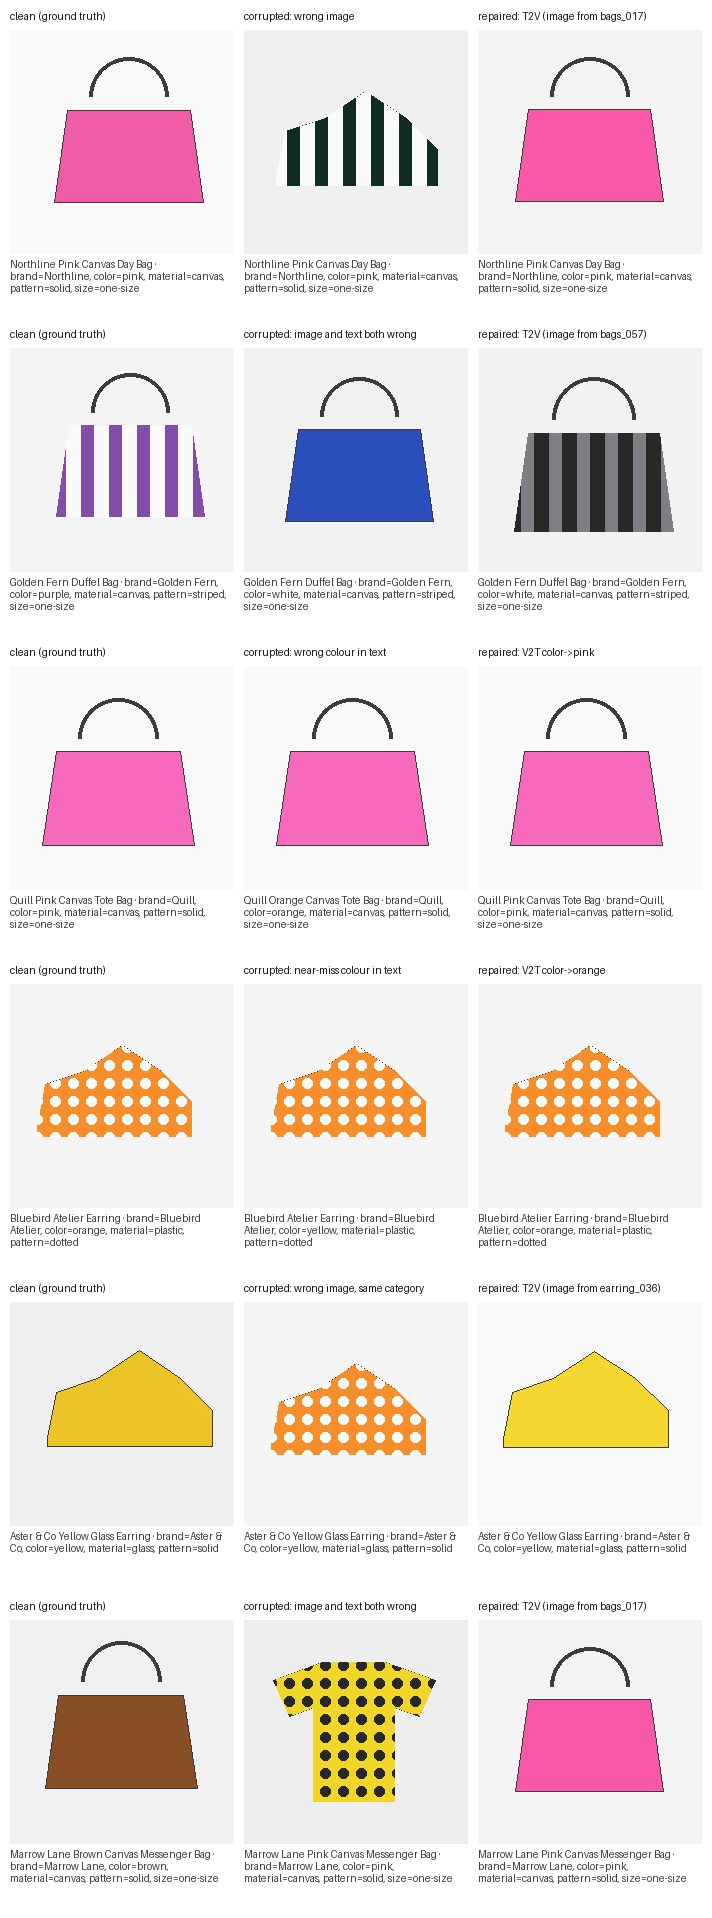

In [15]:
!python -m tiger.cli qualitative-grid --seed 7

from IPython.display import Image as _Image, display
from pathlib import Path as _Path
_g = _Path('paper_figures/qualitative_grid_final.png')
display(_Image(str(_g))) if _g.exists() else print('no grid: no repaired rows in this run')

In [16]:
!cp -r data/outputs data/thresholds data/processed paper_figures /kaggle/working/ 2>/dev/null
# D10: the images the generative fallback just synthesised live under
# data/sample/ and used to be left behind on Kaggle, which is why the
# qualitative grid could never be rebuilt off-platform.
!mkdir -p /kaggle/working/generated && cp -r data/sample/images/generated/. /kaggle/working/generated/ 2>/dev/null
!cd /kaggle/working && zip -rq tiger_corrected_run.zip outputs thresholds processed paper_figures generated
!ls -la /kaggle/working/tiger_corrected_run.zip
print("\n✅ Download tiger_corrected_run.zip from the right sidebar.")

-rw-r--r-- 1 root root 30470583 Sep 14 16:35 /kaggle/working/tiger_corrected_run.zip

✅ Download tiger_corrected_run.zip from the right sidebar.


---
## What to do with these numbers

1. **Compare against `paper_assets/paper_draft_materials.md` §1.** Expect movement.
   Four independent defects fed that table; none of them biased it in a
   predictable direction, so do not assume the corrected numbers are worse.

2. **§7.5 and `ROADMAP_PROGRESS.md` H11 must be rewritten or withdrawn** (E3).
   They explain why Full System and No-Gamma-Gate matched. They matched because
   A1 made them the same run. If the corrected run still shows overlap, prove it
   properly by intersecting the escalated `row_id` sets — identical totals are
   not identical sets.

3. **`reviewer_defense.md` Attack 3 is the urgent one** (E2). It presents the
   47.4% as "safely escalated to a human". They were not: that figure is error
   among rows the system *repaired and committed*. Escalations are the separate
   269. Fix the claim before anyone reads it.

4. **Report N with every accuracy figure.** The CSV now carries them.

5. **Then run the ABO notebook** on this branch. A6 opened the T2V path that was
   closed for the entire cross-domain evaluation, so RQ3's image-repair evidence
   does not exist yet.

Still open and needing you specifically:
- **A2** — pin a Gemini model ID with a live key (`genai.list_models()`), and
  determine whether any published number came from a `--vlm-judge` run.
- **⚑ B6, ⚑ D4** — parked design decisions, not bugs.

## Results

`sweep` gives pooled detection metrics with product-level bootstrap CIs;
`ablate` gives the per-configuration breakdown.

Two things to check against the previous numbers:

* **`full` should still be ≈ P 0.793 / R 0.924 / F1 0.853.** It is unaffected by
  A7 and A8, so a large move means something else changed.
* **`full_fusion` and the per-signal precision table will move**, because A8
  changed what counts as a hit. A probe that previously cleared the floor may
  now be quarantined — that is the correction working, not a regression.

In [17]:
import json
from pathlib import Path

sweep = json.loads(Path("data/outputs/detection_metrics_sweep.json").read_text())
p = sweep["pooled"]
print(f"pooled  P={p['precision']:.3f}  R={p['recall']:.3f}  F1={p['f1']:.3f}"
      f"   (n={p['n_products']} products, {p['n_rows']} rows)")
ci = p.get("bootstrap95_product_level", {})
if ci:
    print(f"  95% CI  P {ci['precision'][0]:.3f}-{ci['precision'][1]:.3f}"
          f"  R {ci['recall'][0]:.3f}-{ci['recall'][1]:.3f}")

print("\nper-error-type recall:")
for lab, v in sorted(p["recall_by_label"].items()):
    print(f"  {lab:<16s} {v['recall']:.3f}  ({v['caught']}/{v['total']})")

abl = json.loads(Path("data/outputs/ablations.json").read_text())
print("\nablations:")
for name in ("random@budget", "text_only", "global_only", "probes_only",
             "no_loo", "full", "full_fusion"):
    if name in abl:
        r = abl[name]
        print(f"  {name:<16s} P={r['precision']:.3f} R={r['recall']:.3f} F1={r['f1']:.3f}")

g, f = abl.get("global_only", {}), abl.get("full", {})
if g and f:
    print(f"\nmutate_text recall: CLIP-only {g['recall_by_label']['mutate_text']['recall']:.3f}"
          f"  ->  with probes {f['recall_by_label']['mutate_text']['recall']:.3f}")
    print("  (this is the paper's strongest verified result -- E9 notes it is")
    print("   currently mis-credited to LOO masking, which contributes nothing here)")

pooled  P=0.738  R=0.869  F1=0.798   (n=572 products, 2860 rows)
  95% CI  P 0.696-0.784  R 0.845-0.893

per-error-type recall:
  missing_image    1.000  (35/35)
  mixed            0.964  (53/55)
  mutate_text      0.779  (304/390)
  swap_image       0.938  (346/369)

ablations:
  random@budget    P=0.313 R=0.369 F1=0.339
  text_only        P=1.000 R=0.084 F1=0.154
  global_only      P=0.783 R=0.543 F1=0.641
  probes_only      P=0.789 R=0.729 F1=0.758
  no_loo           P=0.802 R=0.612 F1=0.695
  full             P=0.738 R=0.869 F1=0.798
  full_fusion      P=0.761 R=0.867 F1=0.811

mutate_text recall: CLIP-only 0.367  ->  with probes 0.779
  (this is the paper's strongest verified result -- E9 notes it is
   currently mis-credited to LOO masking, which contributes nothing here)


## Export

In [18]:
!cp -r data/outputs data/thresholds data/processed /kaggle/working/ 2>/dev/null
!cd /kaggle/working && zip -rq tiger_detection_run.zip outputs thresholds processed
!ls -la /kaggle/working/tiger_detection_run.zip
print("\n✅ Download tiger_detection_run.zip from the right sidebar.")

-rw-r--r-- 1 root root 29802807 Sep 14 16:35 /kaggle/working/tiger_detection_run.zip

✅ Download tiger_detection_run.zip from the right sidebar.


---
## Next

Run **`tiger_abo_corrected_run.ipynb`** for the repair-side numbers on the two
official-ABO verticals. Together they replace every table in `paper_assets/`.

Then `E9`: the ablation labels the contrastive probes "LOO Probes Only" and
"No LOO Masking". Eq. 18 leave-one-out lives in the Analyzer and runs only on
already-flagged rows — it contributes nothing to detection. Correcting this
runs in your favour: the probe result is stronger and more novel than the LOO
story the paper currently tells.